<a href="https://colab.research.google.com/github/nagaraakhil838-debug/Automatic-Image-Captioning-and-Classification-/blob/main/Btp.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import statsmodels.api as sm

# read file
df = pd.read_excel("Amazon_cleaned_optionB_new.xlsx")

# check data types
print(df.dtypes)

# convert numeric columns properly
df['price_new'] = pd.to_numeric(df['price_new'], errors='coerce')
df['mean_return'] = pd.to_numeric(df['mean_return'], errors='coerce')

# drop missing values
df = df.dropna(subset=['price_new','mean_return','brand'])

# create dummy variables for brand
brand_dummies = pd.get_dummies(df['brand'], drop_first=True)

# independent variables
X = pd.concat([df[['price_new']], brand_dummies], axis=1)

# dependent variable
y = df['mean_return']

# convert everything to numeric
X = X.astype(float)
y = y.astype(float)

# add intercept
X = sm.add_constant(X)

# regression
model = sm.OLS(y, X).fit()

print(model.summary())

brand             object
price_new          int64
no_damage          int64
body_damage        int64
screen_damage      int64
mean_return      float64
dtype: object
                            OLS Regression Results                            
Dep. Variable:            mean_return   R-squared:                       0.477
Model:                            OLS   Adj. R-squared:                  0.450
Method:                 Least Squares   F-statistic:                     17.77
Date:                Sat, 12 Sep 2026   Prob (F-statistic):           1.09e-18
Time:                        09:46:05   Log-Likelihood:                -1553.6
No. Observations:                 165   AIC:                             3125.
Df Residuals:                     156   BIC:                             3153.
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t   

In [47]:
from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import pandas as pd
import numpy as np

# X_amazon, y_amazon, X_train_amazon, X_test_amazon, y_train_amazon, y_test_amazon
# are available from the previous Amazon Ridge Regression step

# Define a range of alpha values to search
param_grid_amazon = {'alpha': np.logspace(-4, 4, 100)} # Search from 0.0001 to 10000

# Initialize Ridge Regression model
ridge_amazon = Ridge()

# Initialize GridSearchCV
# cv=5 means 5-fold cross-validation
# scoring='r2' means we'll optimize for R-squared
# n_jobs=-1 uses all available CPU cores
grid_search_amazon = GridSearchCV(ridge_amazon, param_grid_amazon, cv=5, scoring='r2', n_jobs=-1)

# Fit GridSearchCV to the training data
grid_search_amazon.fit(X_train_amazon, y_train_amazon)

# Get the best alpha value and the corresponding score
best_alpha_amazon = grid_search_amazon.best_params_['alpha']
best_r2_cv_amazon = grid_search_amazon.best_score_

print("\n================ AMAZON RIDGE REGRESSION TUNING RESULTS ================")
print(f"Best Alpha: {best_alpha_amazon:.4f}")
print(f"Best R-squared (from cross-validation): {best_r2_cv_amazon:.3f}")

# Now, train the Ridge model with the best alpha on the full training data
best_ridge_model_amazon = Ridge(alpha=best_alpha_amazon)
best_ridge_model_amazon.fit(X_train_amazon, y_train_amazon)

# Evaluate the best model on the test set
y_pred_tuned_amazon = best_ridge_model_amazon.predict(X_test_amazon)
r2_tuned_amazon = r2_score(y_test_amazon, y_pred_tuned_amazon)
mse_tuned_amazon = mean_squared_error(y_test_amazon, y_pred_tuned_amazon)

print(f"R-squared on Test Set (with tuned alpha): {r2_tuned_amazon:.3f}")
print(f"Mean Squared Error on Test Set (with tuned alpha): {mse_tuned_amazon:.3f}")

print("\nModel Coefficients (with tuned alpha):")
coefficients_tuned_amazon = pd.DataFrame({'Feature': X_amazon.columns, 'Coefficient': best_ridge_model_amazon.coef_})
display(coefficients_tuned_amazon)
print(f"Intercept (with tuned alpha): {best_ridge_model_amazon.intercept_:.3f}")


================ AMAZON RIDGE REGRESSION TUNING RESULTS ================
Best Alpha: 10.2353
Best R-squared (from cross-validation): 0.485
R-squared on Test Set (with tuned alpha): -0.328
Mean Squared Error on Test Set (with tuned alpha): 19626335.213

Model Coefficients (with tuned alpha):


,Feature,Coefficient
0,price_new,2929.358005
1,brand_Infinix,-117.589868
2,brand_OnePlus,1120.684080
3,brand_Oppo,-334.174340
4,brand_Poco,254.365458
5,brand_RedMi,1291.333411
6,brand_Samsung,-609.879533
7,brand_Vivo,439.228288


Intercept (with tuned alpha): 5145.088


In [7]:
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np
import pandas as pd

# Prepare the data for Ridge Regression
# Independent variables (X)
X_amazon = df[['price_new', 'brand']].copy()
X_amazon = pd.get_dummies(X_amazon, columns=['brand'], drop_first=True)

# Dependent variable (y)
y_amazon = df['mean_return']

# Standardize numerical features (price_new)
scaler_amazon = StandardScaler()
X_amazon['price_new'] = scaler_amazon.fit_transform(X_amazon[['price_new']])

# Split data into training and testing sets
X_train_amazon, X_test_amazon, y_train_amazon, y_test_amazon = train_test_split(X_amazon, y_amazon, test_size=0.2, random_state=42)

# Initialize and fit the Ridge Regression model
# Alpha is the regularization strength; larger values mean stronger regularization
ridge_model_amazon = Ridge(alpha=1.0) # Starting with alpha=1.0
ridge_model_amazon.fit(X_train_amazon, y_train_amazon)

# Make predictions
y_pred_amazon = ridge_model_amazon.predict(X_test_amazon)

# Evaluate the model
r2_amazon = r2_score(y_test_amazon, y_pred_amazon)
mse_amazon = mean_squared_error(y_test_amazon, y_pred_amazon)

print("\n================ AMAZON RIDGE REGRESSION RESULTS ================")
print(f"R-squared: {r2_amazon:.3f}")
print(f"Mean Squared Error: {mse_amazon:.3f}")

print("\nModel Coefficients:")
coefficients_amazon = pd.DataFrame({'Feature': X_amazon.columns, 'Coefficient': ridge_model_amazon.coef_})
display(coefficients_amazon)
print(f"Intercept: {ridge_model_amazon.intercept_:.3f}")


================ AMAZON RIDGE REGRESSION RESULTS ================
R-squared: -0.666
Mean Squared Error: 24612286.806

Model Coefficients:


,Feature,Coefficient
0,price_new,3418.462367
1,brand_Infinix,1527.353531
2,brand_OnePlus,2502.305153
3,brand_Oppo,1188.620211
4,brand_Poco,1917.347019
5,brand_RedMi,3384.454560
6,brand_Samsung,454.441142
7,brand_Vivo,2231.837310


Intercept: 3626.197


Columns: Index(['mobile', 'price_new', 'flawless', 'good', 'average', 'below_average',
       'mobile_norm', 'mean_return_fk', 'brand'],
      dtype='object')

================ REGRESSION ================
                            OLS Regression Results                            
Dep. Variable:         mean_return_fk   R-squared:                       0.667
Model:                            OLS   Adj. R-squared:                  0.646
Method:                 Least Squares   F-statistic:                     32.47
Date:                Sat, 12 Sep 2026   Prob (F-statistic):           1.12e-30
Time:                        09:54:23   Log-Likelihood:                -1384.0
No. Observations:                 156   AIC:                             2788.
Df Residuals:                     146   BIC:                             2818.
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
     

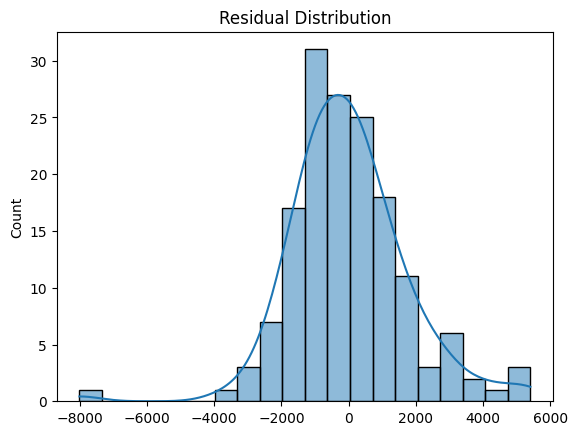

<Figure size 640x480 with 0 Axes>

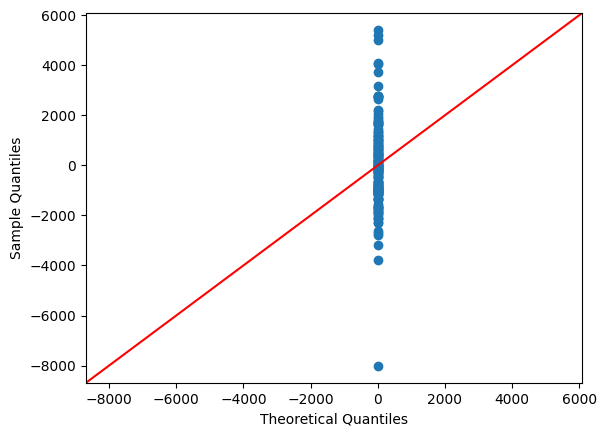

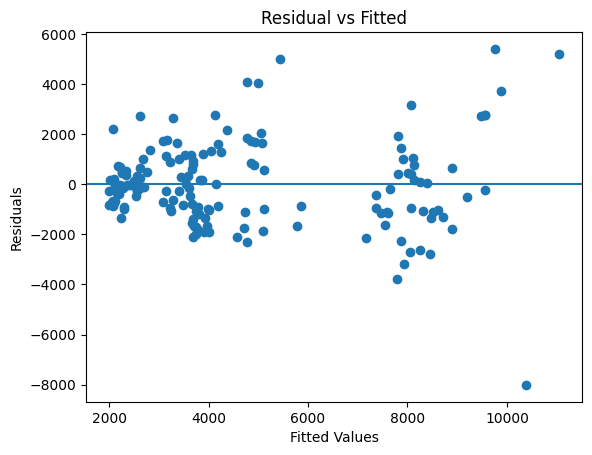

In [12]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.outliers_influence import variance_inflation_factor
from scipy.stats import jarque_bera
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# LOAD DATA
# ==========================================
df = pd.read_excel("Flipkart_cleaned_optionB  .xlsx")

# ==========================================
# CLEAN COLUMN NAMES
# ==========================================
df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")

# Extract brand from 'mobile' column
df['brand'] = df['mobile'].astype(str).str.split(' ').str[0]

print("Columns:", df.columns)

# ==========================================
# CLEAN NUMERIC VARIABLES
# ==========================================
df['price_new'] = (
    df['price_new']
    .astype(str)
    .str.replace(',', '', regex=False)
)

df['price_new'] = pd.to_numeric(df['price_new'], errors='coerce')
df['mean_return_fk'] = pd.to_numeric(df['mean_return_fk'], errors='coerce')

# remove rows with missing values
df = df.dropna(subset=['price_new','mean_return_fk','brand'])

# ==========================================
# REGRESSION
# ==========================================
model = smf.ols('mean_return_fk ~ price_new + C(brand)', data=df).fit()

print("\n================ REGRESSION ================")
print(model.summary())

# ==========================================
# PREPARE MATRIX FOR VIF
# ==========================================
X = pd.get_dummies(df[['price_new','brand']], drop_first=True)

# convert everything to float
X = X.astype(float)

# replace inf values
X = X.replace([np.inf, -np.inf], np.nan)

# drop missing rows
X = X.dropna()

# add intercept
X = sm.add_constant(X)

# ==========================================
# VIF CALCULATION
# ==========================================
print("\n================ VIF ================")

vif = pd.DataFrame()
vif["Variable"] = X.columns
vif["VIF"] = [
    variance_inflation_factor(X.values, i)
    for i in range(X.shape[1])
]

print(vif)

# ==========================================
# NORMALITY TEST
# ==========================================
print("\n================ NORMALITY ================")

residuals = model.resid

jb = jarque_bera(residuals)

print("Jarque-Bera statistic:", jb.statistic)
print("p-value:", jb.pvalue)

# ==========================================
# HISTOGRAM
# ==========================================
plt.figure()
sns.histplot(residuals, kde=True)
plt.title("Residual Distribution")
plt.show()

# ==========================================
# Q-Q PLOT
# ==========================================
plt.figure()
sm.qqplot(residuals, line='45')
plt.show()

# ==========================================
# RESIDUAL VS FITTED
# ==========================================
plt.figure()
plt.scatter(model.fittedvalues, residuals)
plt.axhline(y=0)
plt.xlabel("Fitted Values")
plt.ylabel("Residuals")
plt.title("Residual vs Fitted")
plt.show()

In [14]:
# Display general information about the DataFrame
print(df.info())

# Display descriptive statistics for numerical columns
print("\nDescriptive Statistics:")
display(df.describe())

# Check for missing values
print("\nMissing Values:")
display(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
Index: 156 entries, 3 to 167
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   mobile          156 non-null    object 
 1   price_new       156 non-null    float64
 2   flawless        156 non-null    float64
 3   good            156 non-null    float64
 4   average         156 non-null    float64
 5   below_average   156 non-null    float64
 6   mobile_norm     156 non-null    object 
 7   mean_return_fk  156 non-null    float64
 8   brand           156 non-null    object 
dtypes: float64(6), object(3)
memory usage: 12.2+ KB
None

Descriptive Statistics:


,price_new,flawless,good,average,below_average,mean_return_fk
count,156.000000,156.000000,156.000000,156.000000,156.000000,156.000000
mean,20269.416667,6182.089744,5627.352564,4202.551282,3087.173077,4774.791667
std,14241.706979,3783.664033,3486.619488,2675.317576,2068.610630,2996.996582
min,6193.000000,1200.000000,1080.000000,780.000000,540.000000,900.000000
25%,11724.750000,3287.500000,2936.250000,2136.750000,1481.500000,2465.750000
50%,16999.000000,5250.000000,4837.500000,3493.500000,2475.000000,4037.500000
75%,25249.750000,8587.500000,7880.000000,5797.500000,4187.750000,6571.687500
max,134999.000000,21000.000000,19100.000000,14350.000000,10550.000000,16250.000000



Missing Values:


,0
mobile,0
price_new,0
flawless,0
good,0
average,0
below_average,0
mobile_norm,0
mean_return_fk,0
brand,0


In [16]:
import statsmodels.formula.api as smf

# Run regression with mean_return_fk as target and other relevant columns as predictors
# Removed 'flawless', 'good', 'average', 'below_average' due to potential data leakage
model_flipkart = smf.ols('mean_return_fk ~ price_new + C(brand)', data=df).fit()

print("\n================ FLIPKART REGRESSION RESULTS (Revised) ================")
print(model_flipkart.summary())


================ FLIPKART REGRESSION RESULTS (Revised) ================
                            OLS Regression Results                            
Dep. Variable:         mean_return_fk   R-squared:                       0.667
Model:                            OLS   Adj. R-squared:                  0.646
Method:                 Least Squares   F-statistic:                     32.47
Date:                Sat, 12 Sep 2026   Prob (F-statistic):           1.12e-30
Time:                        09:57:04   Log-Likelihood:                -1384.0
No. Observations:                 156   AIC:                             2788.
Df Residuals:                     146   BIC:                             2818.
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------

In [ ]:
from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np
import pandas as pd

# X_poly_df and y are available from the previous Polynomial Regression step

# Split the polynomial features into training and testing sets
X_train_poly, X_test_poly, y_train, y_test = train_test_split(X_poly_df, y, test_size=0.2, random_state=42)

# Standardize polynomial features
# Initialize a new scaler for polynomial features, as they are different from original X
scaler_poly = StandardScaler()
X_train_poly_scaled = scaler_poly.fit_transform(X_train_poly)
X_test_poly_scaled = scaler_poly.transform(X_test_poly)

# Define a range of alpha values to search
param_grid_ridge_poly = {'alpha': np.logspace(-4, 4, 100)} # Search from 0.0001 to 10000

# Initialize Ridge Regression model
ridge_poly = Ridge()

# Initialize GridSearchCV
grid_search_ridge_poly = GridSearchCV(ridge_poly, param_grid_ridge_poly, cv=5, scoring='r2', n_jobs=-1)

# Fit GridSearchCV to the scaled training data
grid_search_ridge_poly.fit(X_train_poly_scaled, y_train)

# Get the best alpha value and the corresponding score
best_alpha_ridge_poly = grid_search_ridge_poly.best_params_['alpha']
best_r2_ridge_poly = grid_search_ridge_poly.best_score_

print("\n================ RIDGE REGRESSION WITH POLYNOMIAL FEATURES TUNING RESULTS ================")
print(f"Best Alpha (for Polynomial Ridge): {best_alpha_ridge_poly:.4f}")
print(f"Best R-squared (from cross-validation for Poly Ridge): {best_r2_ridge_poly:.3f}")

# Now, train the Ridge model with the best alpha on the full scaled training data
best_ridge_poly_model = Ridge(alpha=best_alpha_ridge_poly)
best_ridge_poly_model.fit(X_train_poly_scaled, y_train)

# Evaluate the best model on the scaled test set
y_pred_ridge_poly = best_ridge_poly_model.predict(X_test_poly_scaled)
r2_ridge_poly = r2_score(y_test, y_pred_ridge_poly)
mse_ridge_poly = mean_squared_error(y_test, y_pred_ridge_poly)

print(f"R-squared on Test Set (with tuned Poly Ridge): {r2_ridge_poly:.3f}")
print(f"Mean Squared Error on Test Set (with tuned Poly Ridge): {mse_ridge_poly:.3f}")

print("\nModel Coefficients (with tuned Poly Ridge - first 10 if many):")
coefficients_ridge_poly = pd.DataFrame({'Feature': X_poly_df.columns, 'Coefficient': best_ridge_poly_model.coef_})
display(coefficients_ridge_poly.head(10))
print(f"Intercept (with tuned Poly Ridge): {best_ridge_poly_model.intercept_:.3f}")

In [48]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler

# --- Prepare X and y for Flipkart data within this cell ---
# Re-create the cleaned df for Flipkart data
df_flipkart = pd.read_excel('Flipkart_cleaned_optionB  .xlsx')
df_flipkart.columns = df_flipkart.columns.str.strip().str.lower().str.replace(" ", "_")
df_flipkart['brand'] = df_flipkart['mobile'].astype(str).str.split(' ').str[0]
df_flipkart['price_new'] = pd.to_numeric(df_flipkart['price_new'].astype(str).str.replace(',', '', regex=False), errors='coerce')
df_flipkart['mean_return_fk'] = pd.to_numeric(df_flipkart['mean_return_fk'], errors='coerce')
df_flipkart = df_flipkart.dropna(subset=['price_new','mean_return_fk','brand'])

X = df_flipkart[['price_new', 'brand']].copy()
X = pd.get_dummies(X, columns=['brand'], drop_first=True)
y = df_flipkart['mean_return_fk']

# Standardize numerical features (price_new) - as per original comments' intent for scaled X
scaler = StandardScaler()
X['price_new'] = scaler.fit_transform(X[['price_new']])

# Create polynomial features (degree=2 as a starting point)
degree = 2
poly = PolynomialFeatures(degree=degree, include_bias=False)
X_poly = poly.fit_transform(X)

# Create a DataFrame for polynomial features for better inspection (optional)
poly_feature_names = poly.get_feature_names_out(X.columns)
X_poly_df = pd.DataFrame(X_poly, columns=poly_feature_names, index=X.index)

# Split the polynomial features into training and testing sets
X_train_poly, X_test_poly, y_train, y_test = train_test_split(X_poly_df, y, test_size=0.2, random_state=42)

# Initialize and fit the Linear Regression model on polynomial features
poly_model = LinearRegression()
poly_model.fit(X_train_poly, y_train)

# Make predictions on the test set
y_pred_poly = poly_model.predict(X_test_poly)

# Evaluate the model
r2_poly = r2_score(y_test, y_pred_poly)
mse_poly = mean_squared_error(y_test, y_pred_poly)

print("\n================ POLYNOMIAL REGRESSION RESULTS ================")
print(f"Polynomial Degree: {degree}")
print(f"R-squared on Test Set: {r2_poly:.3f}")
print(f"Mean Squared Error on Test Set: {mse_poly:.3f}")

print("\nModel Coefficients (first 10 if many):")
coefficients_poly = pd.DataFrame({'Feature': X_poly_df.columns, 'Coefficient': poly_model.coef_})
display(coefficients_poly.head(10))
print(f"Intercept: {poly_model.intercept_:.3f}")


================ POLYNOMIAL REGRESSION RESULTS ================
Polynomial Degree: 2
R-squared on Test Set: -1.100
Mean Squared Error on Test Set: 18267031.060

Model Coefficients (first 10 if many):


,Feature,Coefficient
0,price_new,2052.259831
1,brand_OPPO,562.650102
2,brand_OnePlus,1891.836200
3,brand_Poco,353.505914
4,brand_ROG,526.757581
5,brand_RedMi,1661.552101
6,brand_Samsung,-139.675959
7,brand_Vivo,142.738909
8,brand_asus,146.272811
9,price_new^2,76.390839


Intercept: 3615.844


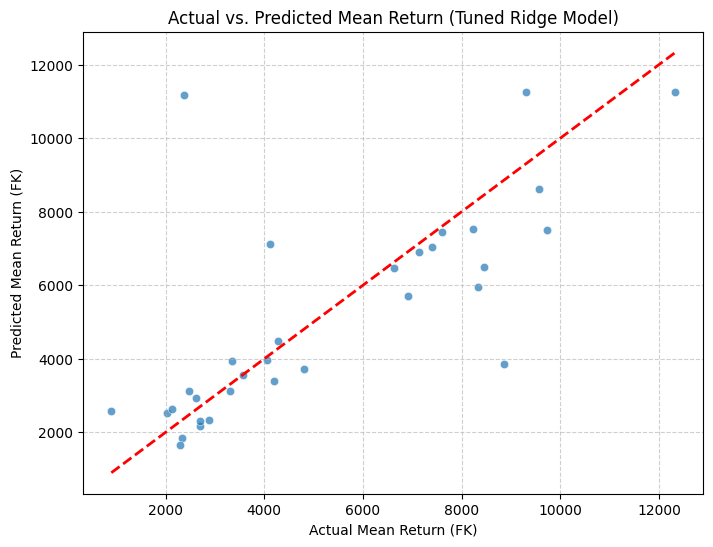

In [45]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test, y=y_pred_ridge_poly, alpha=0.7)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2) # 45-degree line
plt.xlabel('Actual Mean Return (FK)')
plt.ylabel('Predicted Mean Return (FK)')
plt.title('Actual vs. Predicted Mean Return (Tuned Ridge Model)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

In [18]:
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np
import pandas as pd

# Prepare the data for Ridge Regression
# Independent variables (X)
X = df[['price_new', 'brand']].copy()
X = pd.get_dummies(X, columns=['brand'], drop_first=True)

# Dependent variable (y)
y = df['mean_return_fk']

# Standardize numerical features (price_new)
scaler = StandardScaler()
X['price_new'] = scaler.fit_transform(X[['price_new']])

# Add a constant for the intercept, similar to statsmodels
# Note: sklearn's Ridge already handles an intercept, but for comparison with OLS structure, adding explicitly.
# However, it's often omitted when using sklearn's Ridge as it has its own intercept fitting.
# For simplicity with sklearn, we'll let it handle the intercept internally for now.

# Split data into training and testing sets (optional but good practice)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize and fit the Ridge Regression model
# Alpha is the regularization strength; larger values mean stronger regularization
ridge_model = Ridge(alpha=1.0) # You can experiment with different alpha values
ridge_model.fit(X_train, y_train)

# Make predictions
y_pred = ridge_model.predict(X_test)

# Evaluate the model
r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)

print("\n================ RIDGE REGRESSION RESULTS ================")
print(f"R-squared: {r2:.3f}")
print(f"Mean Squared Error: {mse:.3f}")

print("\nModel Coefficients:")
coefficients = pd.DataFrame({'Feature': X.columns, 'Coefficient': ridge_model.coef_})
display(coefficients)
print(f"Intercept: {ridge_model.intercept_:.3f}")


================ RIDGE REGRESSION RESULTS ================
R-squared: -0.263
Mean Squared Error: 10985755.301

Model Coefficients:


,Feature,Coefficient
0,price_new,2000.403945
1,brand_OPPO,829.220190
2,brand_OnePlus,4093.055211
3,brand_Poco,218.225526
4,brand_ROG,-419.973344
5,brand_RedMi,3288.916108
6,brand_Samsung,-501.357473
7,brand_Vivo,377.408069
8,brand_asus,-2885.198972


Intercept: 3805.910


In [21]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import pandas as pd
import numpy as np

# Assuming X and y are already prepared and scaled from the previous Ridge Regression steps
# X = df_flipkart[['price_new', 'brand']].copy()
# X = pd.get_dummies(X, columns=['brand'], drop_first=True)
# y = df_flipkart['mean_return_fk']
# scaler = StandardScaler()
# X['price_new'] = scaler.fit_transform(X[['price_new']])

# Create polynomial features (degree=2 as a starting point)
degree = 2
poly = PolynomialFeatures(degree=degree, include_bias=False)
X_poly = poly.fit_transform(X)

# Create a DataFrame for polynomial features for better inspection (optional)
poly_feature_names = poly.get_feature_names_out(X.columns)
X_poly_df = pd.DataFrame(X_poly, columns=poly_feature_names, index=X.index)

# Split the polynomial features into training and testing sets
X_train_poly, X_test_poly, y_train, y_test = train_test_split(X_poly_df, y, test_size=0.2, random_state=42)

# Initialize and fit the Linear Regression model on polynomial features
poly_model = LinearRegression()
poly_model.fit(X_train_poly, y_train)

# Make predictions on the test set
y_pred_poly = poly_model.predict(X_test_poly)

# Evaluate the model
r2_poly = r2_score(y_test, y_pred_poly)
mse_poly = mean_squared_error(y_test, y_pred_poly)

print("\n================ POLYNOMIAL REGRESSION RESULTS ================")
print(f"Polynomial Degree: {degree}")
print(f"R-squared on Test Set: {r2_poly:.3f}")
print(f"Mean Squared Error on Test Set: {mse_poly:.3f}")

print("\nModel Coefficients (first 10 if many):")
coefficients_poly = pd.DataFrame({'Feature': X_poly_df.columns, 'Coefficient': poly_model.coef_})
display(coefficients_poly.head(10))
print(f"Intercept: {poly_model.intercept_:.3f}")


================ POLYNOMIAL REGRESSION RESULTS ================
Polynomial Degree: 2
R-squared on Test Set: -1.100
Mean Squared Error on Test Set: 18267031.060

Model Coefficients (first 10 if many):


,Feature,Coefficient
0,price_new,2052.259831
1,brand_OPPO,562.650102
2,brand_OnePlus,1891.836200
3,brand_Poco,353.505914
4,brand_ROG,526.757581
5,brand_RedMi,1661.552101
6,brand_Samsung,-139.675959
7,brand_Vivo,142.738909
8,brand_asus,146.272811
9,price_new^2,76.390839


Intercept: 3615.844


In [23]:
from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np
import pandas as pd

# X_poly_df and y are available from the previous Polynomial Regression step

# Split the polynomial features into training and testing sets
X_train_poly, X_test_poly, y_train, y_test = train_test_split(X_poly_df, y, test_size=0.2, random_state=42)

# Standardize polynomial features
# Initialize a new scaler for polynomial features, as they are different from original X
scaler_poly = StandardScaler()
X_train_poly_scaled = scaler_poly.fit_transform(X_train_poly)
X_test_poly_scaled = scaler_poly.transform(X_test_poly)

# Define a range of alpha values to search
param_grid_ridge_poly = {'alpha': np.logspace(-4, 4, 100)} # Search from 0.0001 to 10000

# Initialize Ridge Regression model
ridge_poly = Ridge()

# Initialize GridSearchCV
grid_search_ridge_poly = GridSearchCV(ridge_poly, param_grid_ridge_poly, cv=5, scoring='r2', n_jobs=-1)

# Fit GridSearchCV to the scaled training data
grid_search_ridge_poly.fit(X_train_poly_scaled, y_train)

# Get the best alpha value and the corresponding score
best_alpha_ridge_poly = grid_search_ridge_poly.best_params_['alpha']
best_r2_ridge_poly = grid_search_ridge_poly.best_score_

print("\n================ RIDGE REGRESSION WITH POLYNOMIAL FEATURES TUNING RESULTS ================")
print(f"Best Alpha (for Polynomial Ridge): {best_alpha_ridge_poly:.4f}")
print(f"Best R-squared (from cross-validation for Poly Ridge): {best_r2_ridge_poly:.3f}")

# Now, train the Ridge model with the best alpha on the full scaled training data
best_ridge_poly_model = Ridge(alpha=best_alpha_ridge_poly)
best_ridge_poly_model.fit(X_train_poly_scaled, y_train)

# Evaluate the best model on the scaled test set
y_pred_ridge_poly = best_ridge_poly_model.predict(X_test_poly_scaled)
r2_ridge_poly = r2_score(y_test, y_pred_ridge_poly)
mse_ridge_poly = mean_squared_error(y_test, y_pred_ridge_poly)

print(f"R-squared on Test Set (with tuned Poly Ridge): {r2_ridge_poly:.3f}")
print(f"Mean Squared Error on Test Set (with tuned Poly Ridge): {mse_ridge_poly:.3f}")

print("\nModel Coefficients (with tuned Poly Ridge - first 10 if many):")
coefficients_ridge_poly = pd.DataFrame({'Feature': X_poly_df.columns, 'Coefficient': best_ridge_poly_model.coef_})
display(coefficients_ridge_poly.head(10))
print(f"Intercept (with tuned Poly Ridge): {best_ridge_poly_model.intercept_:.3f}")


================ RIDGE REGRESSION WITH POLYNOMIAL FEATURES TUNING RESULTS ================
Best Alpha (for Polynomial Ridge): 12.3285
Best R-squared (from cross-validation for Poly Ridge): 0.798
R-squared on Test Set (with tuned Poly Ridge): 0.494
Mean Squared Error on Test Set (with tuned Poly Ridge): 4404319.826

Model Coefficients (with tuned Poly Ridge - first 10 if many):


,Feature,Coefficient
0,price_new,997.449986
1,brand_OPPO,221.210416
2,brand_OnePlus,613.104008
3,brand_Poco,105.521191
4,brand_ROG,109.656110
5,brand_RedMi,556.546071
6,brand_Samsung,-39.476750
7,brand_Vivo,73.886202
8,brand_asus,-40.532784
9,price_new^2,-62.939473


Intercept (with tuned Poly Ridge): 4655.498


### Comparison of Model Coefficients

In [26]:
print("\n================ LINEAR OLS MODEL COEFFICIENTS ================")
# The 'model' variable is from the latest OLS regression on Flipkart data (cell 6bb1b387 or wLcC5-lQpMo_)
print(model.params.to_string())

print("\n================ TUNED POLYNOMIAL RIDGE MODEL COEFFICIENTS ================")
# 'coefficients_ridge_poly' is from the previously executed Ridge Regression with Polynomial Features Tuning cell (b5ef56e3)
display(coefficients_ridge_poly)


================ LINEAR OLS MODEL COEFFICIENTS ================
Intercept              1585.893421
C(brand)[T.OPPO]       1577.047467
C(brand)[T.OnePlus]    5688.399495
C(brand)[T.Poco]        847.790982
C(brand)[T.ROG]        1314.040261
C(brand)[T.RedMi]      4727.686225
C(brand)[T.Samsung]    -134.469111
C(brand)[T.Vivo]       1360.253743
C(brand)[T.asus]       -609.495532
price_new                 0.065216

================ TUNED POLYNOMIAL RIDGE MODEL COEFFICIENTS ================


,Feature,Coefficient
0,price_new,997.449986
1,brand_OPPO,221.210416
2,brand_OnePlus,613.104008
3,brand_Poco,105.521191
4,brand_ROG,109.656110
5,brand_RedMi,556.546071
6,brand_Samsung,-39.476750
7,brand_Vivo,73.886202
8,brand_asus,-40.532784
9,price_new^2,-62.939473


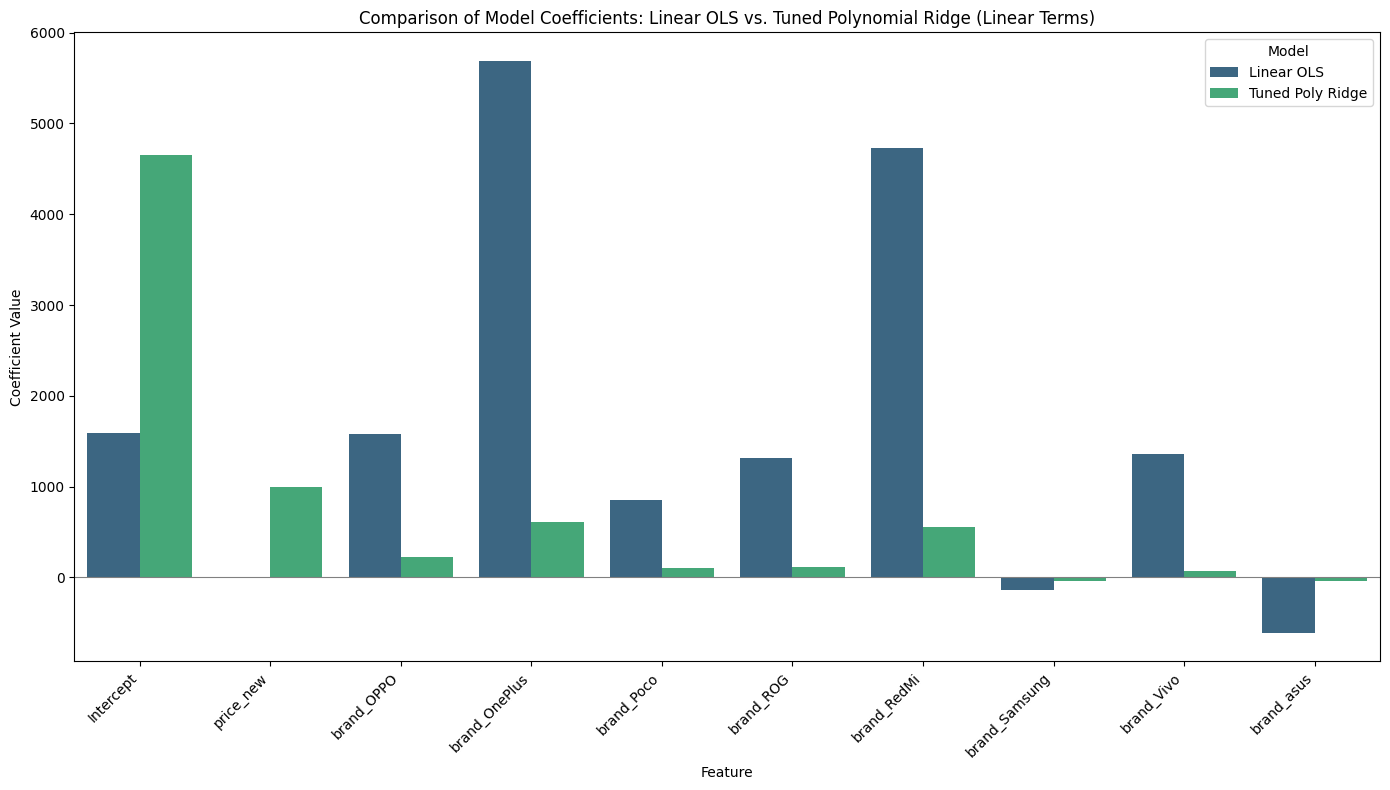

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# --- 1. Prepare OLS Coefficients ---
ols_coef_series = model.params
ols_features = []
ols_coefficients = []

# Add Intercept
ols_features.append('Intercept')
ols_coefficients.append(ols_coef_series['Intercept'])

# Add price_new
ols_features.append('price_new')
ols_coefficients.append(ols_coef_series['price_new'])

# Add brand dummies
for feature_name in ols_coef_series.index:
    if feature_name.startswith('C(brand)[T.'):
        brand_name = feature_name.replace('C(brand)[T.', '').replace(']', '')
        ols_features.append(f'brand_{brand_name}')
        ols_coefficients.append(ols_coef_series[feature_name])

ols_df_for_plot = pd.DataFrame({
    'Feature': ols_features,
    'Coefficient': ols_coefficients,
    'Model': 'Linear OLS'
})

# --- 2. Prepare Tuned Polynomial Ridge Coefficients (Linear Terms) ---
ridge_poly_features = []
ridge_poly_coefficients = []

# Add Intercept
ridge_poly_features.append('Intercept')
ridge_poly_coefficients.append(best_ridge_poly_model.intercept_)

# Extract 'price_new' (linear term)
# Ensure 'price_new' exists in coefficients_ridge_poly before accessing
if 'price_new' in coefficients_ridge_poly['Feature'].values:
    price_new_coef_ridge = coefficients_ridge_poly[coefficients_ridge_poly['Feature'] == 'price_new']['Coefficient'].iloc[0]
    ridge_poly_features.append('price_new')
    ridge_poly_coefficients.append(price_new_coef_ridge)

# Extract 'brand_' linear terms
for _, row in coefficients_ridge_poly.iterrows():
    feature = row['Feature']
    coefficient = row['Coefficient']
    if feature.startswith('brand_') and '^2' not in feature and ' ' not in feature: # Exclude squared and interaction terms
        ridge_poly_features.append(feature)
        ridge_poly_coefficients.append(coefficient)

ridge_poly_df_for_plot = pd.DataFrame({
    'Feature': ridge_poly_features,
    'Coefficient': ridge_poly_coefficients,
    'Model': 'Tuned Poly Ridge'
})

# --- 3. Combine DataFrames ---
combined_coef_df = pd.concat([ols_df_for_plot, ridge_poly_df_for_plot])

# --- 4. Generate Side-by-Side Bar Chart ---
plt.figure(figsize=(14, 8))
sns.barplot(x='Feature', y='Coefficient', hue='Model', data=combined_coef_df, palette='viridis')
plt.title('Comparison of Model Coefficients: Linear OLS vs. Tuned Polynomial Ridge (Linear Terms)')
plt.xlabel('Feature')
plt.ylabel('Coefficient Value')
plt.xticks(rotation=45, ha='right')
plt.axhline(0, color='grey', linewidth=0.8) # Add a horizontal line at y=0
plt.tight_layout()
plt.show()

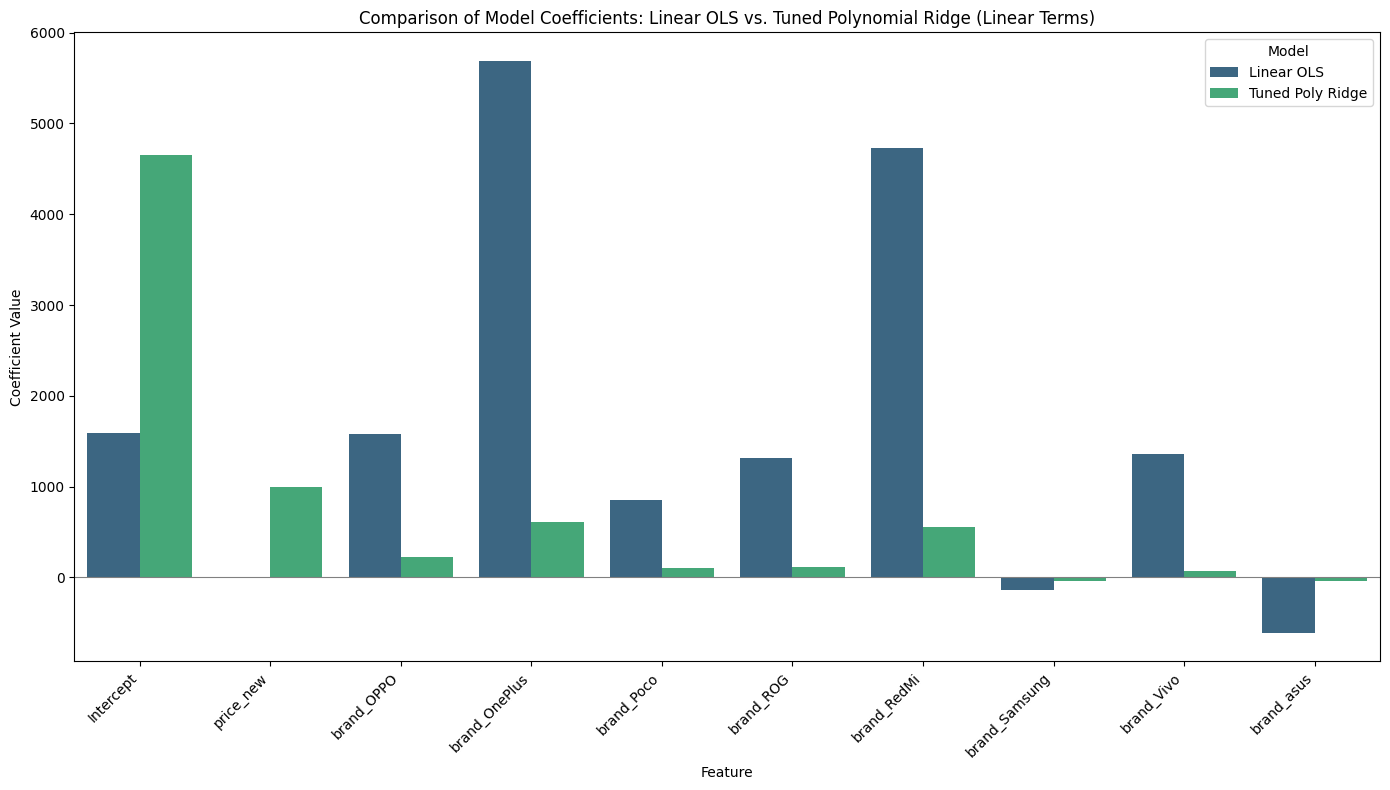

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# --- 1. Prepare OLS Coefficients ---
ols_coef_series = model.params
ols_features = []
ols_coefficients = []

# Add Intercept
ols_features.append('Intercept')
ols_coefficients.append(ols_coef_series['Intercept'])

# Add price_new
ols_features.append('price_new')
ols_coefficients.append(ols_coef_series['price_new'])

# Add brand dummies
for feature_name in ols_coef_series.index:
    if feature_name.startswith('C(brand)[T.'):
        brand_name = feature_name.replace('C(brand)[T.', '').replace(']', '')
        ols_features.append(f'brand_{brand_name}')
        ols_coefficients.append(ols_coef_series[feature_name])

ols_df_for_plot = pd.DataFrame({
    'Feature': ols_features,
    'Coefficient': ols_coefficients,
    'Model': 'Linear OLS'
})

# --- 2. Prepare Tuned Polynomial Ridge Coefficients (Linear Terms) ---
ridge_poly_features = []
ridge_poly_coefficients = []

# Add Intercept
ridge_poly_features.append('Intercept')
ridge_poly_coefficients.append(best_ridge_poly_model.intercept_)

# Extract 'price_new' (linear term)
price_new_coef_ridge = coefficients_ridge_poly[coefficients_ridge_poly['Feature'] == 'price_new']['Coefficient'].iloc[0]
ridge_poly_features.append('price_new')
ridge_poly_coefficients.append(price_new_coef_ridge)

# Extract 'brand_' linear terms
for _, row in coefficients_ridge_poly.iterrows():
    feature = row['Feature']
    coefficient = row['Coefficient']
    if feature.startswith('brand_') and '^2' not in feature and ' ' not in feature: # Exclude squared and interaction terms
        ridge_poly_features.append(feature)
        ridge_poly_coefficients.append(coefficient)

ridge_poly_df_for_plot = pd.DataFrame({
    'Feature': ridge_poly_features,
    'Coefficient': ridge_poly_coefficients,
    'Model': 'Tuned Poly Ridge'
})

# --- 3. Combine DataFrames ---
combined_coef_df = pd.concat([ols_df_for_plot, ridge_poly_df_for_plot])

# --- 4. Generate Side-by-Side Bar Chart ---
plt.figure(figsize=(14, 8))
sns.barplot(x='Feature', y='Coefficient', hue='Model', data=combined_coef_df, palette='viridis')
plt.title('Comparison of Model Coefficients: Linear OLS vs. Tuned Polynomial Ridge (Linear Terms)')
plt.xlabel('Feature')
plt.ylabel('Coefficient Value')
plt.xticks(rotation=45, ha='right')
plt.axhline(0, color='grey', linewidth=0.8) # Add a horizontal line at y=0
plt.tight_layout()
plt.show()

### Interpretation of Coefficient Comparison

This bar chart visually compares the coefficients of the linear terms present in both the Ordinary Least Squares (OLS) model and the Tuned Polynomial Ridge Regression model. Key observations include:

*   **Magnitude Differences**: You'll notice that the coefficients for the Tuned Polynomial Ridge model are generally smaller in magnitude compared to the Linear OLS model. This is a characteristic effect of Ridge regularization, which shrinks coefficients towards zero to prevent overfitting.

*   **Intercept**: The intercept values, representing the baseline `mean_return_fk` when all other features are zero (or at their reference level for categorical variables), can differ significantly between the models due to the different ways they model the relationships and apply regularization.

*   **Relative Importance**: While the absolute magnitudes differ, the relative importance and direction (positive or negative) of some features might remain consistent across both models, indicating robust relationships. However, in the Ridge model, the influence of individual features is attenuated, making the model less sensitive to outliers or multicollinearity.

*   **Exclusion of Non-Linear Terms**: It's important to remember that this comparison focuses only on the *linear* terms (e.g., `price_new`, `brand_OPPO`). The polynomial Ridge model also incorporates squared terms (`price_new^2`) and interaction terms (e.g., `price_new brand_OPPO`), which contribute to its overall predictive power but are not explicitly shown in this linear comparison for clarity.

In [30]:
import pandas as pd

df_flipkart = pd.read_excel('Flipkart_cleaned_optionB  .xlsx')
display(df_flipkart.head())

,mobile,price_new,flawless,good,average,below_average,mobile_norm,mean_return_fk
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,asus 6z,43499.0,3450.0,3105.0,2242.0,1642.0,asus 6z,2609.75
4,asus rog phone 7,74999.0,6600.0,5940.0,4290.0,3150.0,asus rog phone 7,4995.00


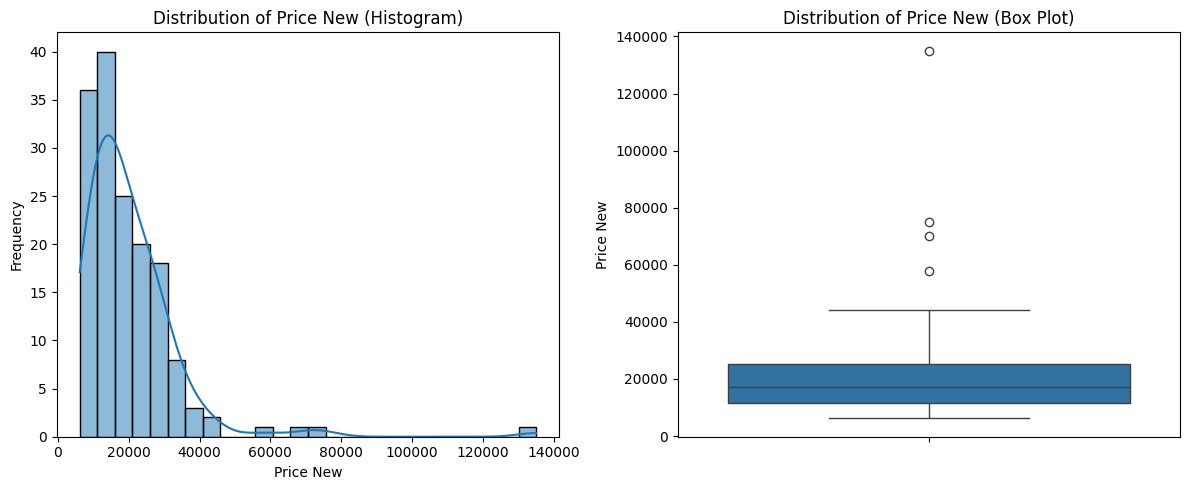

In [32]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 5))

# Histogram
plt.subplot(1, 2, 1) # 1 row, 2 columns, first plot
sns.histplot(df_flipkart['price_new'], kde=True)
plt.title('Distribution of Price New (Histogram)')
plt.xlabel('Price New')
plt.ylabel('Frequency')

# Box plot
plt.subplot(1, 2, 2) # 1 row, 2 columns, second plot
sns.boxplot(y=df_flipkart['price_new'])
plt.title('Distribution of Price New (Box Plot)')
plt.ylabel('Price New')

plt.tight_layout()
plt.show()

In [34]:
import pandas as pd

df_flipkart = pd.read_excel('Flipkart_cleaned_optionB  .xlsx')
display(df_flipkart.head())

,mobile,price_new,flawless,good,average,below_average,mobile_norm,mean_return_fk
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,asus 6z,43499.0,3450.0,3105.0,2242.0,1642.0,asus 6z,2609.75
4,asus rog phone 7,74999.0,6600.0,5940.0,4290.0,3150.0,asus rog phone 7,4995.00


Columns in dataset:
Index(['brand', 'price_new', 'no_damage', 'body_damage', 'screen_damage',
       'mean_return'],
      dtype='object')

================ REGRESSION RESULTS ================
                            OLS Regression Results                            
Dep. Variable:            mean_return   R-squared:                       0.477
Model:                            OLS   Adj. R-squared:                  0.450
Method:                 Least Squares   F-statistic:                     17.77
Date:                Sat, 12 Sep 2026   Prob (F-statistic):           1.09e-18
Time:                        10:17:00   Log-Likelihood:                -1553.6
No. Observations:                 165   AIC:                             3125.
Df Residuals:                     156   BIC:                             3153.
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                 

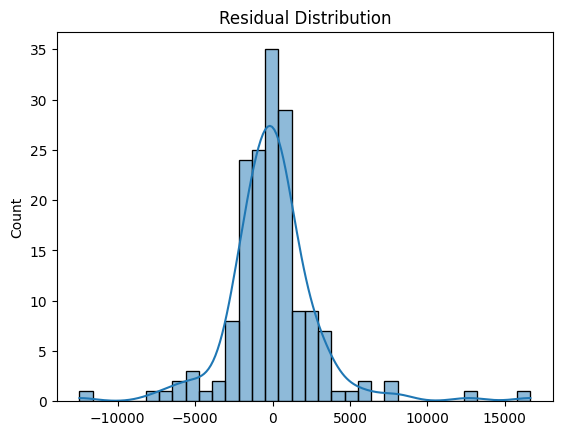

<Figure size 640x480 with 0 Axes>

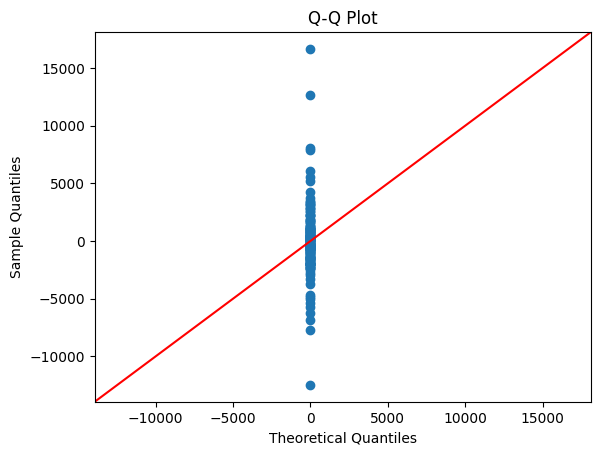

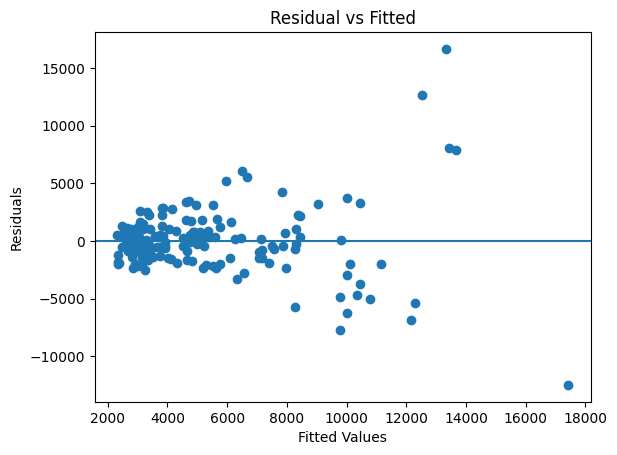

In [37]:
# ==========================================
# IMPORT LIBRARIES
# ==========================================
import pandas as pd
import numpy as np
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.outliers_influence import variance_inflation_factor
from scipy.stats import jarque_bera
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# LOAD AMAZON DATASET
# ==========================================
df = pd.read_excel("Amazon_cleaned_optionB_new.xlsx")

# ==========================================
# CLEAN COLUMN NAMES
# ==========================================
df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")

print("Columns in dataset:")
print(df.columns)

# ==========================================
# CLEAN NUMERIC VARIABLES
# ==========================================
df['price_new'] = (
    df['price_new']
    .astype(str)
    .str.replace(',', '', regex=False)
)

df['price_new'] = pd.to_numeric(df['price_new'], errors='coerce')
df['mean_return'] = pd.to_numeric(df['mean_return'], errors='coerce')

# remove missing rows
df = df.dropna(subset=['price_new','mean_return','brand'])

# ==========================================
# RUN REGRESSION
# ==========================================
model = smf.ols('mean_return ~ price_new + C(brand)', data=df).fit()

print("\n================ REGRESSION RESULTS ================")
print(model.summary())

# ==========================================
# PREPARE MATRIX FOR VIF
# ==========================================
X = pd.get_dummies(df[['price_new','brand']], drop_first=True)

# convert to numeric
X = X.astype(float)

# remove infinite values
X = X.replace([np.inf, -np.inf], np.nan)

# drop missing rows
X = X.dropna()

# add constant
X = sm.add_constant(X)

# ==========================================
# CALCULATE VIF
# ==========================================
print("\n================ VIF TEST ================")

vif = pd.DataFrame()
vif["Variable"] = X.columns
vif["VIF"] = [
    variance_inflation_factor(X.values, i)
    for i in range(X.shape[1])
]

print(vif)

# ==========================================
# NORMALITY TEST
# ==========================================
print("\n================ NORMALITY TEST ================")

residuals = model.resid

jb = jarque_bera(residuals)

print("Jarque-Bera statistic:", jb.statistic)
print("p-value:", jb.pvalue)

# ==========================================
# HISTOGRAM OF RESIDUALS
# ==========================================
plt.figure()
sns.histplot(residuals, kde=True)
plt.title("Residual Distribution")
plt.show()

# ==========================================
# Q-Q PLOT
# ==========================================
plt.figure()
sm.qqplot(residuals, line='45')
plt.title("Q-Q Plot")
plt.show()

# ==========================================
# RESIDUAL VS FITTED
# ==========================================
plt.figure()
plt.scatter(model.fittedvalues, residuals)
plt.axhline(y=0)
plt.xlabel("Fitted Values")
plt.ylabel("Residuals")
plt.title("Residual vs Fitted")
plt.show()

In [38]:
import os

# List all files in the current directory
files_in_env = os.listdir('/content/')

# Check if the desired file exists
file_to_check = 'Amazon_cleaned_optionB_final.xlsx'
if file_to_check in files_in_env:
    print(f"'{file_to_check}' exists in the environment.")
else:
    print(f"'{file_to_check}' does not exist in the environment. Available files: {files_in_env}")

'Amazon_cleaned_optionB_final.xlsx' does not exist in the environment. Available files: ['.config', '.ipynb_checkpoints', 'Amazon_cleaned_optionB_new.xlsx', 'Flipkart_cleaned_optionB  .xlsx', 'sample_data']


In [43]:
import pandas as pd
import numpy as np
import statsmodels.api as sm

# 1. Load the dataset (using the already loaded df_new_dataset)
df = df_new_dataset.copy() # Use the DataFrame loaded from New-Dataset.xlsx

# 2. Preprocessing & Encoding
# Strip whitespace and ensure lower case for mapping
df['platform(X3)'] = df['platform(X3)'].str.strip().str.lower()
df['condition(X4)'] = df['condition(X4)'].str.strip().str.lower()

# Mapping values based on your study's design
platform_map = {'amazon': 1, 'flipkart': 2}
condition_map = {'flawless': 0, 'good': 1, 'average': 2, 'below average': 1}

df['X3_encoded'] = df['platform(X3)'].map(platform_map)
df['X4_encoded'] = df['condition(X4)'].map(condition_map)

# 3. Handle Brand Dummies (Reference Category: Asus)
df_encoded = pd.get_dummies(df, columns=['Brand(X1)'], drop_first=True)

# 4. Define Features (X) and Target (Y)
features = ['New price(X2)', 'X3_encoded', 'X4_encoded'] + \
           [col for col in df_encoded.columns if col.startswith('Brand(X1)_')]

X = df_encoded[features].astype(float)
X = sm.add_constant(X) # Add Intercept
Y = df_encoded['Return price(Y)']

# 5. Fit the Multiple Linear Regression (OLS)
model = sm.OLS(Y, X).fit()

# 6. Create and Format the Beta Table
beta_table = pd.DataFrame({
    'Variable': model.params.index,
    'Beta Coefficient (Weight)': model.params.values,
    'Standard Error': model.bse.values,
    't-statistic': model.tvalues.values,
    'P-value': model.pvalues.values
})

# Renaming for report clarity
variable_mapping = {
    'const': 'Intercept (Beta 0)',
    'New price(X2)': 'New Price (X2)',
    'X3_encoded': 'Platform (X3)',
    'X4_encoded': 'Condition (X4)'
}
beta_table['Variable'] = beta_table['Variable'].replace(variable_mapping)
beta_table['Variable'] = beta_table['Variable'].str.replace('Brand(X1)_', 'Brand: ', regex=False)

# Display the final report table
print("--- Regression Beta Coefficients Table ---")
print(beta_table.to_string(index=False))

# Optional: Save to CSV for Excel use
# beta_table.to_csv('Beta_Values_Report.csv', index=False)

--- Regression Beta Coefficients Table ---
          Variable  Beta Coefficient (Weight)  Standard Error  t-statistic      P-value
Intercept (Beta 0)                3092.707841      506.549766     6.105437 1.417721e-09
    New Price (X2)                   0.085656        0.006031    14.203608 3.542718e-42
     Platform (X3)                -741.183317      160.562909    -4.616155 4.367685e-06
    Condition (X4)                -650.825000      105.016567    -6.197356 8.094639e-10
    Brand: Infinix                 685.812758      411.824625     1.665303 9.613605e-02
    Brand: OnePlus                5682.406664      419.290441    13.552436 8.090812e-39
       Brand: Oppo                1210.440844      435.217402     2.781233 5.507436e-03
       Brand: Poco                1468.914008      456.613544     3.216974 1.333147e-03
      Brand: RedMi                4589.780557      438.311768    10.471497 1.575507e-24
    Brand: Samsung                 144.204854      476.040853     0.302925 7.

In [41]:
import pandas as pd

# Load the 'New-Dataset.xlsx' file using pd.read_excel
df_new_dataset = pd.read_excel('New-Dataset.xlsx')

# Display the first few rows to verify
display(df_new_dataset.head())

,Brand(X1),New price(X2),platform(X3),condition(X4),Return price(Y)
0,Asus,43499,Flipkart,Flawless,3450
1,Asus,74999,Flipkart,Flawless,6600
2,Asus,39990,Flipkart,Flawless,5150
3,Asus,33499,Flipkart,Flawless,6650
4,Asus,43999,Flipkart,Flawless,5050
